In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\Learning Data Analytics\Python\Luke's Tutorial\Python_Data_Analytics_Course-main\data_jobs.csv")

In [3]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
def clean_list(skill_list):
    if pd.notna(skill_list):
       return ast.literal_eval(skill_list)

df['job_skills'] = df['job_skills'].apply(clean_list)

In [5]:
df_DA = df[df['job_title_short'] == 'Data Analyst']
df_DA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:00,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
12,Data Analyst,Stagiaire Data Analyst (H/F) - Lyon (69006),"Lyon, France",via Jobijoba,Full-time and Internship,False,France,2023-12-22 13:24:00,False,False,France,NaN,NaN,NaN,Engie,"[sql, php, excel, power bi, sap, jira]","{'analyst_tools': ['excel', 'power bi', 'sap']..."
18,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:00,False,False,Poland,NaN,NaN,NaN,Glovo,"[sql, python, r, redshift, pandas, excel, look...","{'analyst_tools': ['excel', 'looker', 'tableau..."
31,Data Analyst,Stage - Data Analyst F/H,"Paris, France",via LinkedIn,Full-time and Internship,False,France,2023-10-19 13:59:00,False,False,France,NaN,NaN,NaN,GROUPE BON MARCHÉ : Le Bon Marché Rive Gauche ...,[sql],{'programming': ['sql']}
34,Data Analyst,Data Analyst als Marketing Manager Automation ...,"Erlangen, Germany",via Central Illinois Proud Jobs,Full-time,False,Germany,2023-02-23 13:31:00,True,False,Germany,NaN,NaN,NaN,DEFACTO GmbH,[sap],{'analyst_tools': ['sap']}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:00,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,None,NaN
785705,Data Analyst,Expert Business Data Analyst - Now Hiring,"Oakland, CA",via Snagajob,Full-time,False,"California, United States",2023-01-09 06:00:00,False,False,United States,NaN,NaN,NaN,PG&E Corporation,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
785715,Data Analyst,Amul Careers 2023 - Apply Online - Data Analys...,India,melalui Jobsleworld - Jobs In India - Job Vaca...,Pekerjaan tetap,False,India,2023-03-13 06:16:00,False,False,India,NaN,NaN,NaN,Amul,None,NaN
785717,Data Analyst,Data & Analytics Architect (w/m/x),"Erfurt, Jerman",melalui LinkedIn,Pekerjaan tetap,False,Germany,2023-03-12 06:18:00,False,False,Germany,NaN,NaN,NaN,NTT DATA DACH,"[aws, azure]","{'cloud': ['aws', 'azure']}"


In [6]:
df_explode = df_DA.explode('job_skills')

In [7]:
df_explode['job_posted_month_no'] = df_explode['job_posted_date'].dt.month

In [8]:
df_pivot = df_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)

In [9]:
df_pivot.loc['Total'] =  df_pivot.sum()
df_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [10]:
df_pivot = df_pivot[df_pivot.loc['Total'].sort_values(ascending = False).index]
df_pivot = df_pivot.drop('Total')

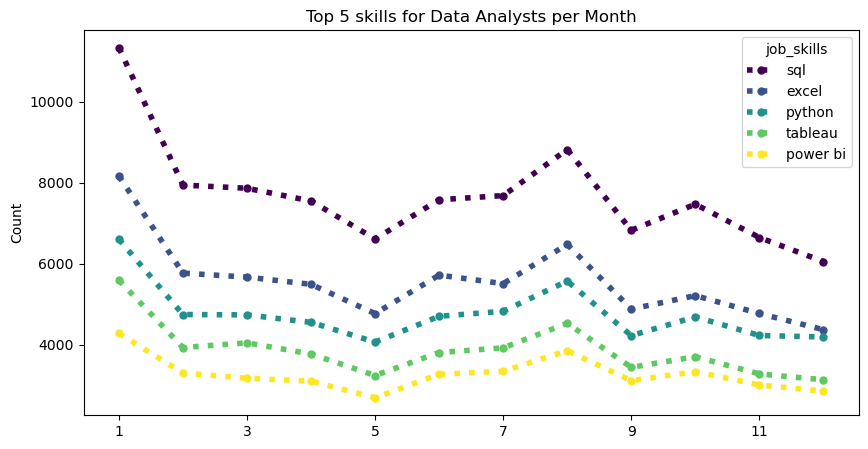

In [33]:
df_pivot.iloc[0:, 0:5].plot(
    kind = 'line',
    linewidth = 4,
    linestyle = ':', #'.','-','--'
    colormap = 'viridis',
    marker = 'o',
    markersize = 5,
    figsize = (10,5)
)
plt.title('Top 5 skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [12]:
#df_explode.groupby('job_skills')['salary_year_avg'].agg(['size','median'])
skill_stats = df_explode.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    medain_salary = ('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values('skill_count', ascending = False).head(20)
skill_stats

,skill_count,medain_salary
job_skills,,
sql,92428,92500.0000
excel,66860,84479.0000
python,57190,98500.0000
tableau,46455,95000.0000
power bi,39380,90000.0000
r,29996,92527.5000
sas,27998,90000.0000
powerpoint,13822,85000.0000
word,13562,80000.0000


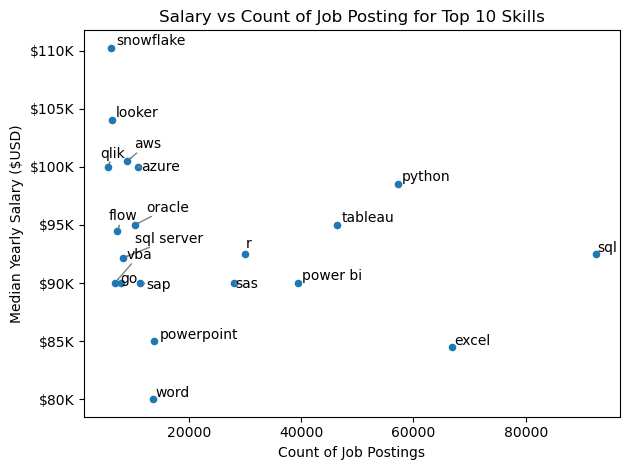

In [30]:
from adjustText import adjust_text

skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'medain_salary')

texts = []

for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i],skill_stats['medain_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle="->", color = 'grey', lw = 1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs Count of Job Posting for Top 10 Skills')
plt.tight_layout() 
    
plt.show()

In [17]:
#!pip install adjustText